Dataset Path: C:\Users\Deepthi V\.cache\kagglehub\datasets\jp797498e\twitter-entity-sentiment-analysis\versions\2

First 5 Rows:
     ID       Entity Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               Tweet  
0  I am coming to the borders and I will kill you...  
1  im getting on borderlands and i will kill you ...  
2  im coming on borderlands and i will murder you...  
3  im getting on borderlands 2 and i will murder ...  
4  im getting into borderlands and i can murder y...  

Dataset Shape:
(74681, 4)

Sentiment Counts:
Sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


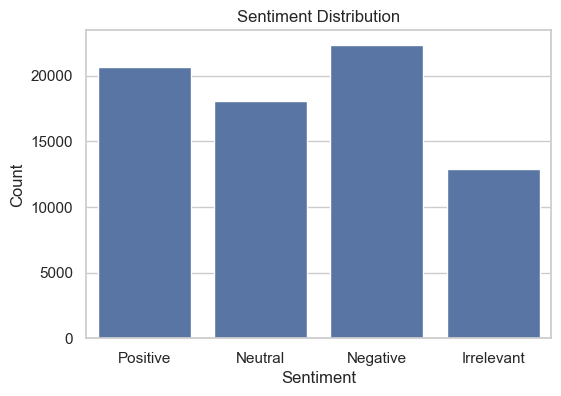

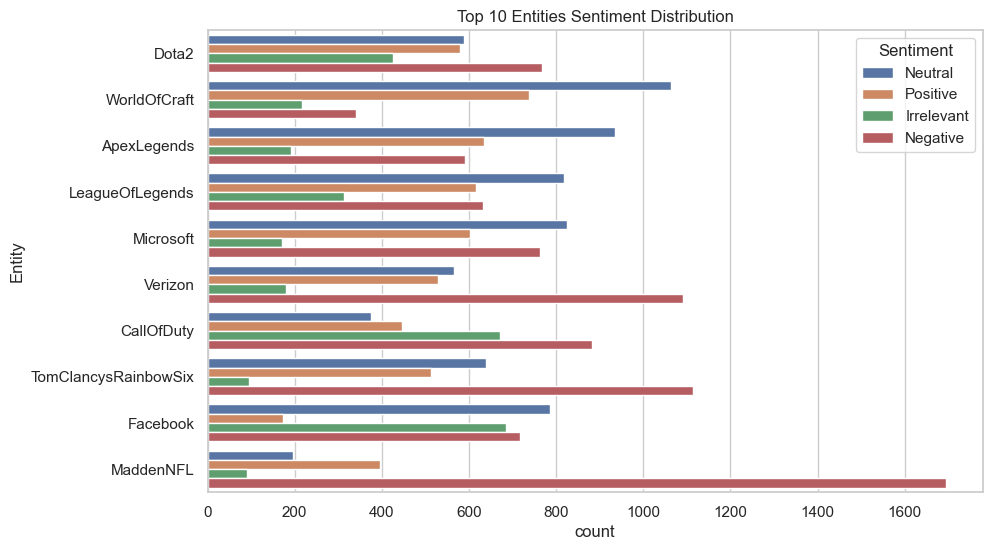

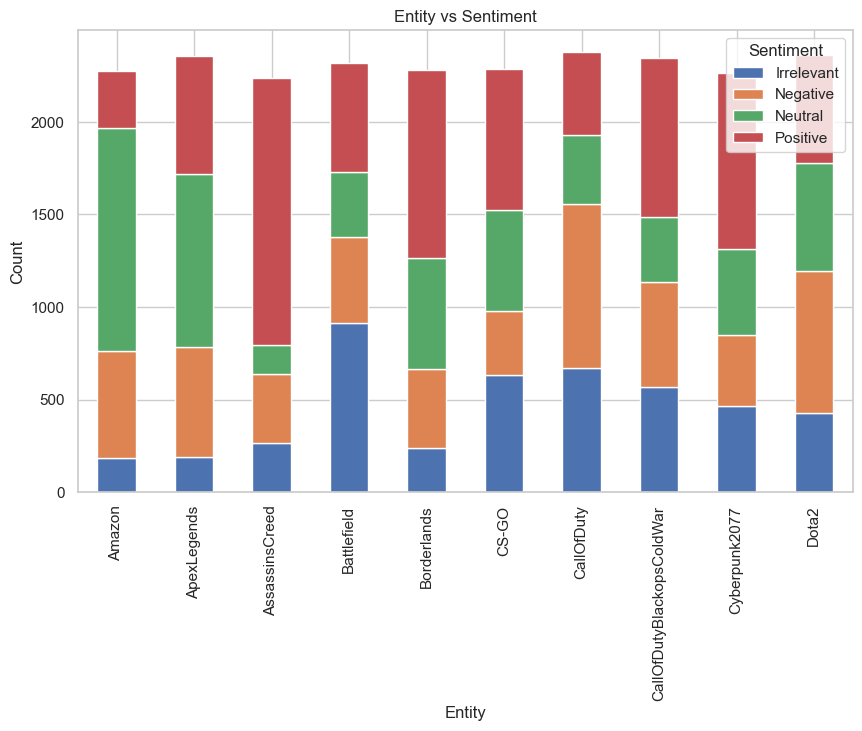

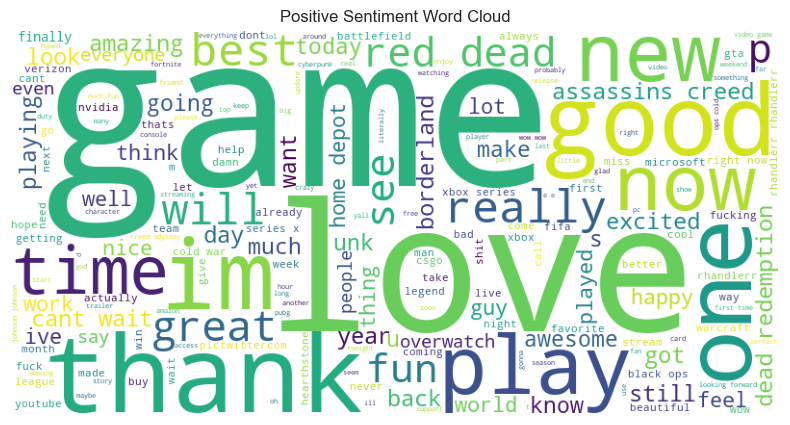

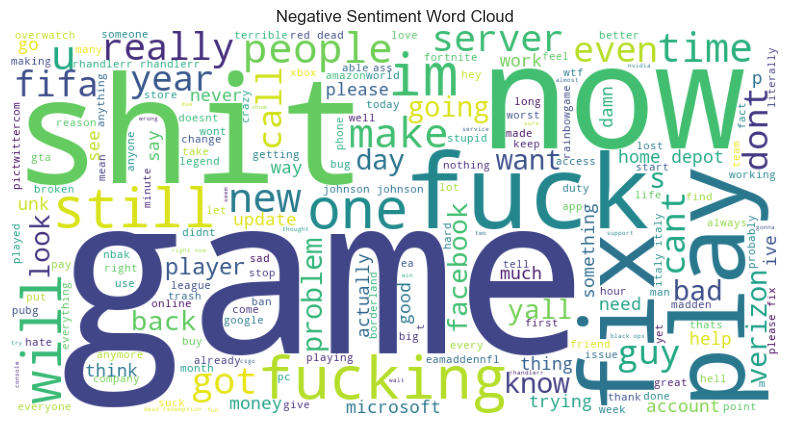

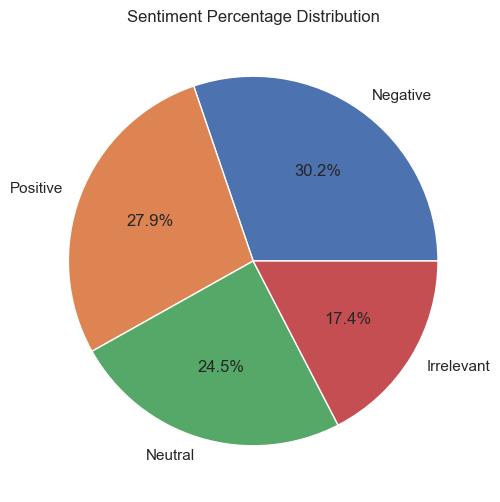

In [2]:
# pip install kagglehub wordcloud seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import kagglehub
import os
import re

sns.set(style="whitegrid")

path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print("Dataset Path:", path)

file_path = os.path.join(path, "twitter_training.csv")

df = pd.read_csv(file_path)

# Rename columns
df.columns = ['ID', 'Entity', 'Sentiment', 'Tweet']

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nSentiment Counts:")
print(df['Sentiment'].value_counts())

# Remove missing values
df = df.dropna()

# Text Cleaning Function
def clean_text(text):
    text = str(text)
    
    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtags
    text = re.sub(r"#\w+", "", text)

    # Remove special characters
    text = re.sub(r"[^A-Za-z\s]", "", text)

    text = text.lower()
    return text

df['Clean_Tweet'] = df['Tweet'].apply(clean_text)

# SENTIMENT DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# ENTITY-WISE SENTIMENT ANALYSIS

plt.figure(figsize=(10,6))
top_entities = df['Entity'].value_counts().index[:10]

sns.countplot(
    y='Entity',
    hue='Sentiment',
    data=df[df['Entity'].isin(top_entities)]
)

plt.title("Top 10 Entities Sentiment Distribution")
plt.show()

# SENTIMENT BY ENTITY (STACKED BAR)

entity_sentiment = pd.crosstab(
    df['Entity'],
    df['Sentiment']
)

entity_sentiment.head(10).plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title("Entity vs Sentiment")
plt.ylabel("Count")
plt.show()

# WORD CLOUD - POSITIVE

positive_text = " ".join(
    df[df['Sentiment'] == 'Positive']['Clean_Tweet']
)

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("Positive Sentiment Word Cloud")
plt.show()

# WORD CLOUD - NEGATIVE

negative_text = " ".join(
    df[df['Sentiment'] == 'Negative']['Clean_Tweet']
)

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Negative Sentiment Word Cloud")
plt.show()

# PIE CHART SENTIMENT DISTRIBUTION

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage Distribution")
plt.show()